In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.orbital.kepler_propagator import (cartesian_to_elements, elements_to_cartesian,
                                              propagate, julian_date, AU_KM)
from src.simulation.monte_carlo import close_approach_monte_carlo, summarize_monte_carlo
from src.config.paths import FIGURES_DIR, RESULTS_DIR

plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
EARTH_RADIUS_KM = 6371.0

In [2]:
r0_eq = np.array([-4.098530841632175E-01, 9.070198866066711E-01, 3.267919471115156E-01])
v0_eq = np.array([-1.507552412168823E-02, -3.713559927658847E-03, -1.761867987218290E-03])
EPOCH_APOPHIS = 2459215.5

EPS = np.radians(23.43928)  # obliquity of the ecliptic, J2000
def eq_to_ecl(vec):
    x, y, z = vec
    return np.array([x, np.cos(EPS)*y + np.sin(EPS)*z, -np.sin(EPS)*y + np.cos(EPS)*z])

r0_apophis = eq_to_ecl(r0_eq)
v0_apophis = eq_to_ecl(v0_eq)

earth_elements = {"a": 1.00000011, "e": 0.01671022, "i": 0.0, "Omega": 0.0,
                   "omega": np.radians(102.94719), "M0": np.radians(357.51716)}
EPOCH_EARTH = 2451545.0

a0, e0, i0, Om0, om0, M0_0 = cartesian_to_elements(r0_apophis, v0_apophis)
print(f"Apophis elements: a={a0:.6f} AU, e={e0:.6f}, i={np.degrees(i0):.4f} deg")
print(f"  Omega={np.degrees(Om0):.4f} deg, omega={np.degrees(om0):.4f} deg, M0={np.degrees(M0_0):.4f} deg")

Apophis elements: a=0.922507 AU, e=0.191522, i=3.3367 deg
  Omega=204.0390 deg, omega=126.6520 deg, M0=127.3226 deg


In [3]:
target_jd = julian_date(datetime(2029, 4, 13, 21, 46))

# Scenario A: real, tiny current uncertainty (well-tracked object)
result_A = close_approach_monte_carlo(
    r0_object=r0_apophis, v0_object=v0_apophis, epoch_object_jd=EPOCH_APOPHIS,
    earth_elements=earth_elements, epoch_earth_jd=EPOCH_EARTH,
    target_jd=target_jd, window_days=5,
    pos_sigma_km=1.0, vel_sigma_mm_s=0.5, n_sim=3000, seed=42,
)
summary_A = summarize_monte_carlo(result_A["min_distances_km"])
print("Scenario A (current well-determined orbit):")
print(summary_A)

Scenario A (current well-determined orbit):
{'mean_km': 298739.3192502544, 'std_km': 335.6239793226704, 'p5_km': 298187.15571822977, 'p50_km': 298737.8344491262, 'p95_km': 299289.2433283061, 'impact_fraction': 0.0, 'n_samples': 3000}


In [4]:
# Scenario B: short-observation-arc sensitivity study
result_B = close_approach_monte_carlo(
    r0_object=r0_apophis, v0_object=v0_apophis, epoch_object_jd=EPOCH_APOPHIS,
    earth_elements=earth_elements, epoch_earth_jd=EPOCH_EARTH,
    target_jd=target_jd, window_days=5,
    pos_sigma_km=50000, vel_sigma_mm_s=200, n_sim=3000, seed=42,
)
summary_B = summarize_monte_carlo(result_B["min_distances_km"])
print("Scenario B (short observation arc, sensitivity study):")
print(summary_B)

print(f"\nNominal 2-body closest approach: {result_A['nominal_min_km']:,.0f} km")
print("(JPL's full-perturbation published value: ~38,000 km -- the gap is expected;")
print("see Part 3 below for how N-body/perturbation modeling closes this gap)")

Scenario B (short observation arc, sensitivity study):
{'mean_km': 4888421.69139065, 'std_km': 3681415.5459238607, 'p5_km': 395841.17503961816, 'p50_km': 4122800.359174642, 'p95_km': 11942686.782760324, 'impact_fraction': 0.0, 'n_samples': 3000}

Nominal 2-body closest approach: 298,745 km
(JPL's full-perturbation published value: ~38,000 km -- the gap is expected;
see Part 3 below for how N-body/perturbation modeling closes this gap)


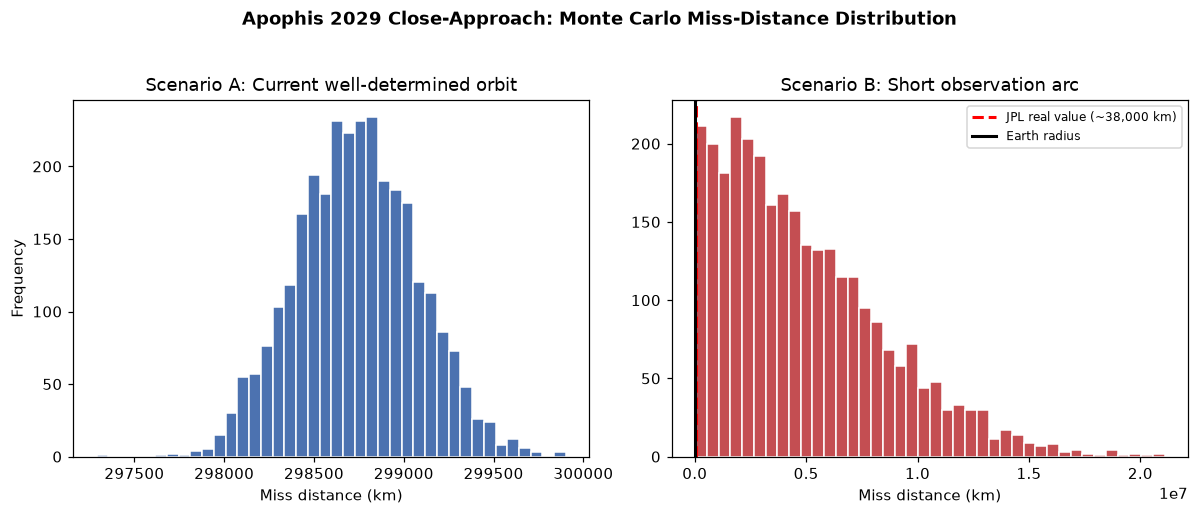

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(result_A["min_distances_km"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Scenario A: Current well-determined orbit")
axes[0].set_xlabel("Miss distance (km)"); axes[0].set_ylabel("Frequency")
axes[0].ticklabel_format(useOffset=False, style="plain", axis="x")

axes[1].hist(result_B["min_distances_km"], bins=40, color="#C44E52", edgecolor="white")
axes[1].axvline(38000, color="red", ls="--", lw=2, label="JPL real value (~38,000 km)")
axes[1].axvline(EARTH_RADIUS_KM, color="black", ls="-", lw=2, label="Earth radius")
axes[1].set_title("Scenario B: Short observation arc")
axes[1].set_xlabel("Miss distance (km)"); axes[1].legend(fontsize=8)
plt.suptitle("Apophis 2029 Close-Approach: Monte Carlo Miss-Distance Distribution", fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mc_01_apophis_histograms.png", bbox_inches="tight")
plt.show()

In [6]:
from src.simulation.monte_carlo import perturb_elements, condition_code_to_sigma_frac
from src.orbital.kepler_propagator import solve_kepler

preds_path = RESULTS_DIR / "asteroid_predictions_for_simulation.csv"
if preds_path.exists():
    preds = pd.read_csv(preds_path).drop_duplicates(subset="full_name", keep="first")
    top = preds.sort_values("risk_score", ascending=False).head(6).reset_index(drop=True)
    print(top[["full_name", "pha", "diameter_km", "moid_au", "condition_code", "risk_score"]])
else:
    print(f"[INFO] {preds_path} not found -- run notebook 06_risk_scoring.ipynb first")
    print("to generate the ML risk predictions this sweep depends on.")
    top = None

               full_name  pha  diameter_km  moid_au  condition_code  \
0   1981 Midas (1973 EA)    1     3.400000  0.00277             0.0   
1         4953 (1990 MU)    1     3.753712  0.02450             0.0   
2  2329 Orthos (1976 WA)    0     4.329731  0.09360             0.0   
3      242450 (2004 QY2)    1     2.914000  0.04790             0.0   
4   5731 Zeus (1988 VP4)    0     5.231000  0.06470             0.0   
5     144332 (2004 DV24)    1     1.700047  0.00560             0.0   

   risk_score  
0   10.000000  
1    9.997426  
2    9.994852  
3    9.992278  
4    9.989704  
5    9.987130  


In [7]:
rng = np.random.default_rng(42)
N_SIM = 1500
sim_results = {}

if top is not None:
    for idx, row in top.iterrows():
        sigma_frac = condition_code_to_sigma_frac(row.get("condition_code", 5))
        a_samp, e_samp = perturb_elements(row["a"], row["e"], sigma_frac, N_SIM, rng)
        q_samp = a_samp * (1 - e_samp)
        sim_results[row["full_name"]] = {"q_samples": q_samp, "sigma_frac": sigma_frac,
                                            "condition_code": row.get("condition_code", 5)}
        print(f"{row['full_name']}: condition_code={row.get('condition_code',5):.0f}, "
              f"sigma={sigma_frac:.1%}, q_mean={q_samp.mean():.4f} AU, q_std={q_samp.std():.5f} AU")

1981 Midas (1973 EA): condition_code=0, sigma=0.2%, q_mean=0.6208 AU, q_std=0.00266 AU
4953 (1990 MU): condition_code=0, sigma=0.2%, q_mean=0.5552 AU, q_std=0.00246 AU
2329 Orthos (1976 WA): condition_code=0, sigma=0.2%, q_mean=0.8359 AU, q_std=0.00356 AU
242450 (2004 QY2): condition_code=0, sigma=0.2%, q_mean=0.5668 AU, q_std=0.00155 AU
5731 Zeus (1988 VP4): condition_code=0, sigma=0.2%, q_mean=0.7872 AU, q_std=0.00334 AU
144332 (2004 DV24): condition_code=0, sigma=0.2%, q_mean=1.0107 AU, q_std=0.00217 AU


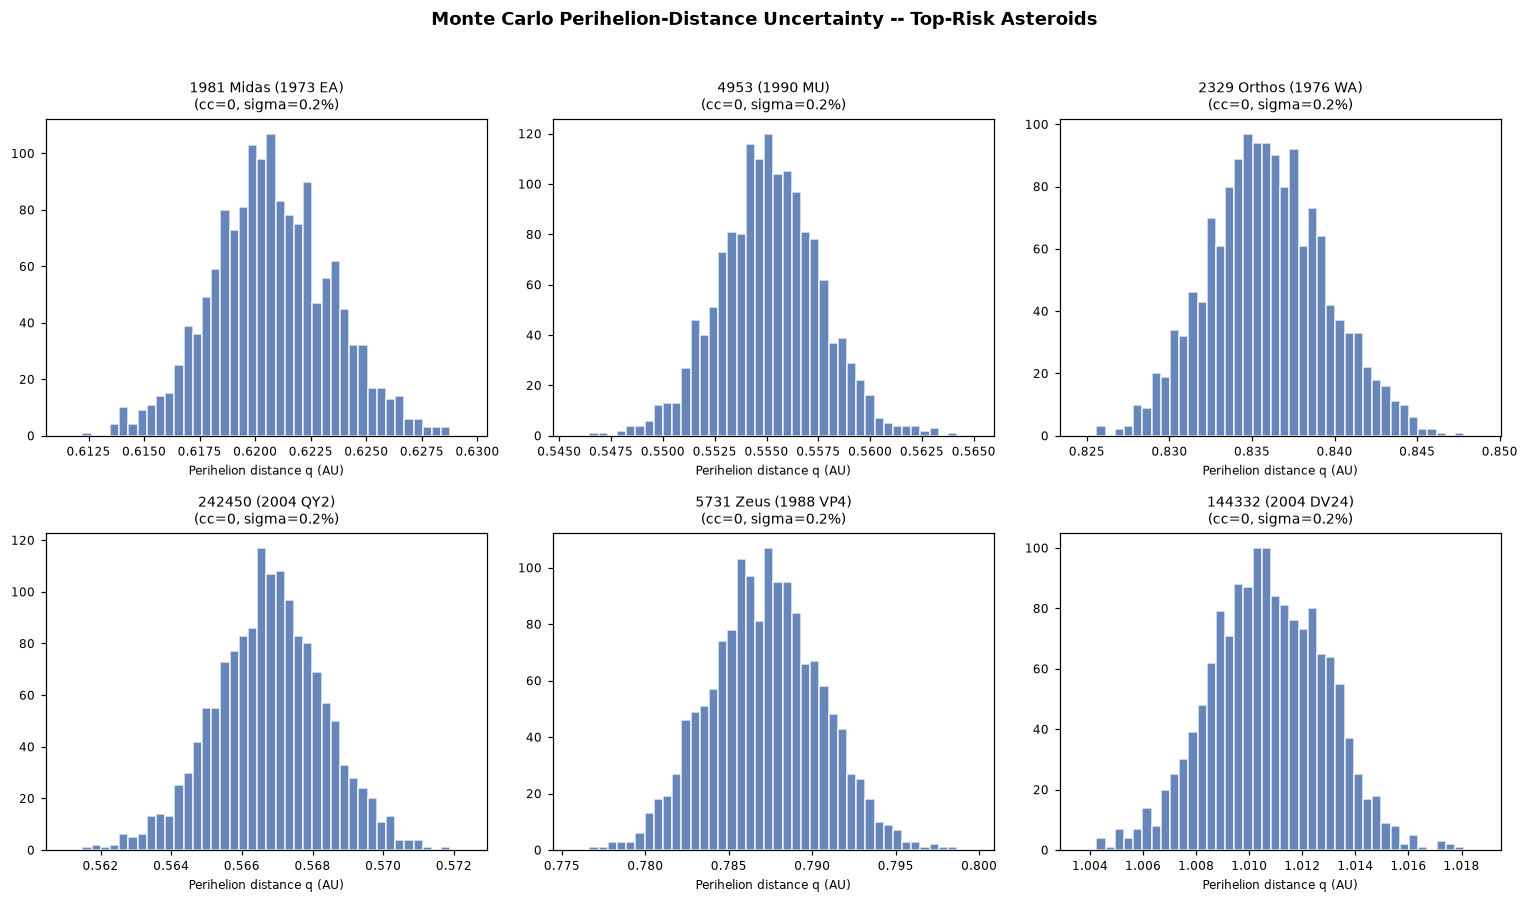

In [8]:
if top is not None:
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, (name, sim) in zip(axes.flat, sim_results.items()):
        q = sim["q_samples"]
        ax.hist(q, bins=40, color="#4C72B0", edgecolor="white", alpha=0.85)
        pad = (q.max() - q.min()) * 0.1 or 0.01
        ax.set_xlim(q.min() - pad, q.max() + pad)
        ax.set_title(f"{name}\n(cc={sim['condition_code']:.0f}, sigma={sim['sigma_frac']:.1%})", fontsize=9)
        ax.set_xlabel("Perihelion distance q (AU)", fontsize=8)
        ax.tick_params(labelsize=8)
    plt.suptitle("Monte Carlo Perihelion-Distance Uncertainty -- Top-Risk Asteroids", fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "mc_02_multi_asteroid_perihelion.png", bbox_inches="tight")
    plt.show()

In [12]:
import rebound.horizons
rebound.horizons.SSL_CONTEXT = 'unverified'
from src.simulation.nbody import build_solar_system_sim, integrate_and_track_distance, REBOUND_AVAILABLE

if REBOUND_AVAILABLE:
    sim = build_solar_system_sim(epoch_jd=EPOCH_APOPHIS, target_body="99942")
    for i, p in enumerate(sim.particles):
        print(f"Index {i}: m={p.m:.3e}, x={p.x:.4f}, y={p.y:.4f}, z={p.z:.4f}")
    # Confirm correct indices by inspecting sim.particles, then:
    result = integrate_and_track_distance(sim, target_index=9, earth_index=3,
                                             t_start_days=0, t_end_days=3000)
    print(f"N-body min distance: {result['min_distance_km']:,.0f} km")
else:
    print("rebound not installed -- install with: pip install rebound")
    print("then re-run this cell to compare N-body vs two-body vs JPL's published result.")

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Mercury'... 
Found: Mercury Barycenter (199) (chosen from query 'Mercury')
Searching NASA Horizons for 'Venus'... 
Found: Venus Barycenter (299) (chosen from query 'Venus')
Searching NASA Horizons for '399'... 
Found: Earth (399) 
Searching NASA Horizons for '499'... 
Found: Mars (499) 
Searching NASA Horizons for '599'... 
Found: Jupiter (599) 
Searching NASA Horizons for '699'... 
Found: Saturn (699) 
Searching NASA Horizons for '799'... 
Found: Uranus (799) 
Searching NASA Horizons for '899'... 
Found: Neptune (899) 
Searching NASA Horizons for '99942'... 
Found: 99942 Apophis (2004 MN4) 
Index 0: m=1.000e+00, x=-0.0066, y=0.0060, z=0.0001
Index 1: m=1.660e-07, x=0.2304, y=-0.3520, z=-0.0509
Index 2: m=2.448e-06, x=-0.4531, y=-0.5639, z=0.0180
Index 3: m=3.003e-06, x=-0.1858, y=0.9728, z=0.0001
Index 4: m=3.227e-07, x=0.6142, y=1.3817, z=0.0137
Index 5: m=9.546e-04, x=3.0348, y=-4.0822, z=-0.0510
Ind

c:\Users\SATYAM\Desktop\ISM_Assignments\neo-forecasting\venv\Lib\site-packages\rebound\horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)
